## Actividad 
Con las siguientes imagen realiza las siguientes condiciones.

<img src="IMG/img1.jpg" alt="imagen 1" width="200">
<img src="IMG/img2.jpg" alt="imagen 1" width="200">

* Establece el fondo en rojo, azul, verde.
* Convertir a escala de grises
* Convertir a de BGR a RGB.
* Establecer un umbral y que este sea el más optimo
* Reduce la imagen aun tamaña de 100 y convierte a escala de grises
* Establece el fondo de la imagen de color roja y establece un umbral





Para la primera imagen el umbral debe detallar el sol de la imagen

para la segunda imagen el umbral debe detallar el contorno de la image circular

In [77]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(6399.5), np.float64(3999.5), np.float64(-0.5))

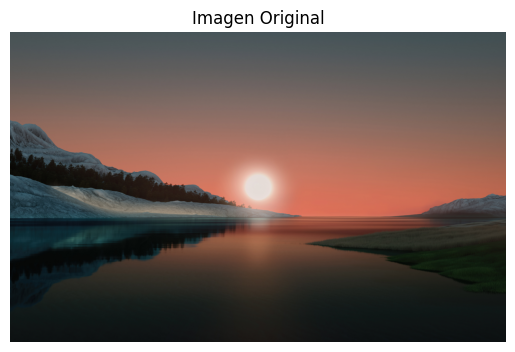

In [78]:
img = cv2.imread('IMG/img1.jpg')

# Mostrar imagen original (OpenCV usa BGR)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original")
plt.axis('off')

Fondo en rojo, azul y verde

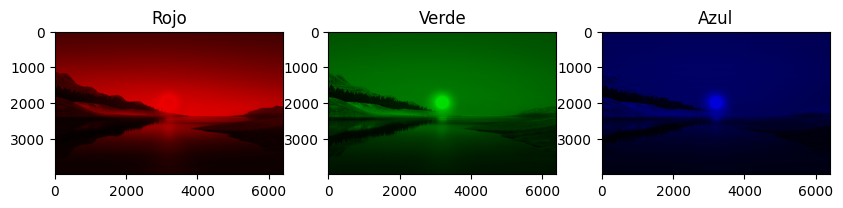

In [79]:
# Crear copias
img_rojo = img.copy()
img_verde = img.copy()
img_azul = img.copy()

# Aplicar filtros (anulando canales)
img_rojo[:,:,1] = 0
img_rojo[:,:,0] = 0

img_verde[:,:,2] = 0
img_verde[:,:,0] = 0

img_azul[:,:,2] = 0
img_azul[:,:,1] = 0

# Mostrar
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img_rojo, cv2.COLOR_BGR2RGB))
plt.title("Rojo")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(img_verde, cv2.COLOR_BGR2RGB))
plt.title("Verde")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(img_azul, cv2.COLOR_BGR2RGB))
plt.title("Azul")

plt.show()

Escala de grises

(np.float64(-0.5), np.float64(6399.5), np.float64(3999.5), np.float64(-0.5))

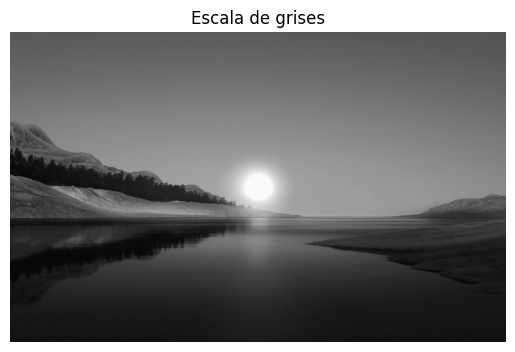

In [80]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Escala de grises")
plt.axis('off')

Convertir de BGR a RGB

(np.float64(-0.5), np.float64(6399.5), np.float64(3999.5), np.float64(-0.5))

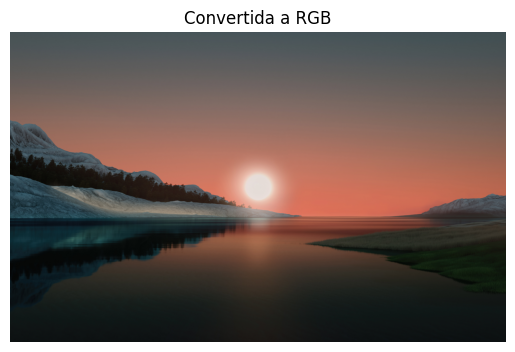

In [81]:
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(rgb)
plt.title("Convertida a RGB")
plt.axis('off')

Umbral óptimo (Otsu)

In [ ]:
# Umbral automático
_, thresh_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(thresh_otsu, cmap='gray')
plt.title("Umbral Óptimo (Otsu)")
plt.axis('off')

(np.float64(-0.5), np.float64(6399.5), np.float64(3999.5), np.float64(-0.5))

Redimensionar a 100x100 y convertir a gris

(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

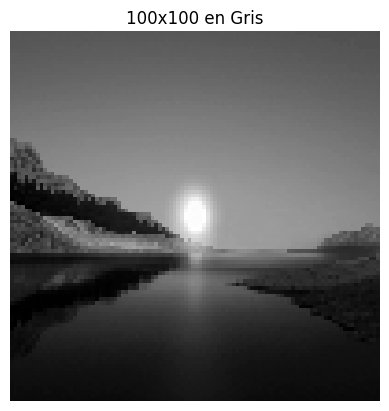

In [ ]:
small = cv2.resize(img, (100,100))
small_gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)

plt.imshow(small_gray, cmap='gray')
plt.title("100x100 en Gris")
plt.axis('off')

Fondo rojo + umbral

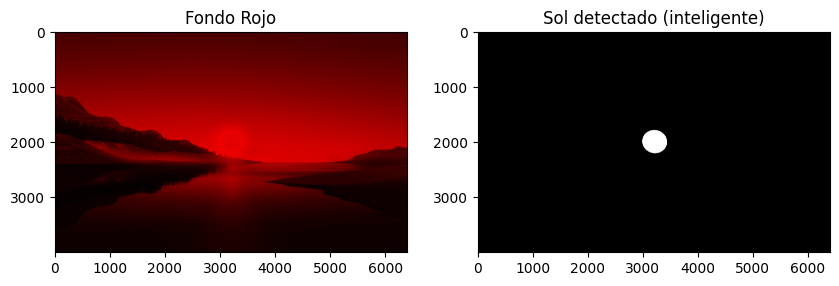

In [ ]:
# Fondo rojo
fondo_rojo = img.copy()
fondo_rojo[:,:,1] = 0
fondo_rojo[:,:,0] = 0

# Escala de grises
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Separar canales
b, g, r = cv2.split(img)

# 🔥 Umbral dinámico basado en la imagen
umbral_brillo = gris.max() - 30   # puedes ajustar entre 20–40

# 🔥 Condición inteligente: brillo alto + rojo alto
mask = (gris > umbral_brillo) & (r > 150)

thresh_sol = mask.astype(np.uint8) * 255

# 🔥 Limpiar ruido
kernel = np.ones((5,5), np.uint8)
thresh_sol = cv2.morphologyEx(thresh_sol, cv2.MORPH_OPEN, kernel)

# 🔥 Quedarse con el objeto más grande (el sol)
contornos, _ = cv2.findContours(thresh_sol, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask_final = np.zeros_like(thresh_sol)

if contornos:
    c = max(contornos, key=cv2.contourArea)
    cv2.drawContours(mask_final, [c], -1, 255, -1)

# Mostrar
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(fondo_rojo, cv2.COLOR_BGR2RGB))
plt.title("Fondo Rojo")

plt.subplot(1,2,2)
plt.imshow(mask_final, cmap='gray')
plt.title("Sol detectado (inteligente)")

plt.show()

Cargar segunda  imagen

(np.float64(-0.5), np.float64(3839.5), np.float64(2399.5), np.float64(-0.5))

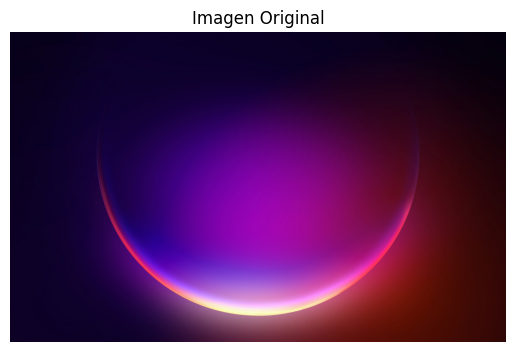

In [ ]:
img = cv2.imread('IMG/img2.jpg')

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original")
plt.axis('off')

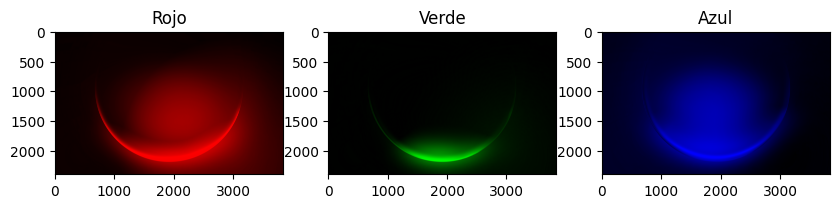

In [ ]:
fondo_rojo = img.copy()
fondo_verde = img.copy()
fondo_azul = img.copy()

# Rojo
fondo_rojo[:,:,1] = 0
fondo_rojo[:,:,0] = 0

# Verde
fondo_verde[:,:,2] = 0
fondo_verde[:,:,0] = 0

# Azul
fondo_azul[:,:,2] = 0
fondo_azul[:,:,1] = 0

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(fondo_rojo, cv2.COLOR_BGR2RGB))
plt.title("Rojo")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(fondo_verde, cv2.COLOR_BGR2RGB))
plt.title("Verde")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(fondo_azul, cv2.COLOR_BGR2RGB))
plt.title("Azul")

plt.show()

Escala de grises

(np.float64(-0.5), np.float64(3839.5), np.float64(2399.5), np.float64(-0.5))

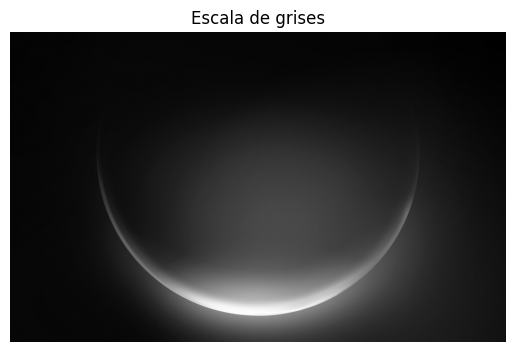

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Escala de grises")
plt.axis('off')

Convertir de BGR a RGB

(np.float64(-0.5), np.float64(3839.5), np.float64(2399.5), np.float64(-0.5))

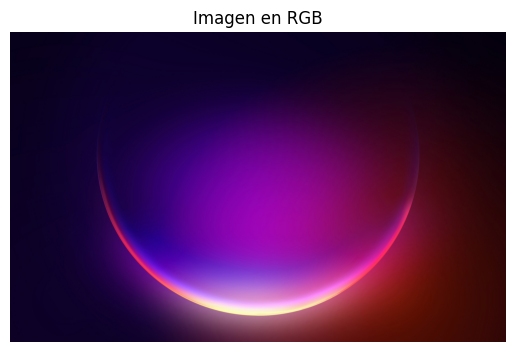

In [ ]:
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(rgb)
plt.title("Imagen en RGB")
plt.axis('off')

Umbral óptimo (Otsu)

(np.float64(-0.5), np.float64(3839.5), np.float64(2399.5), np.float64(-0.5))

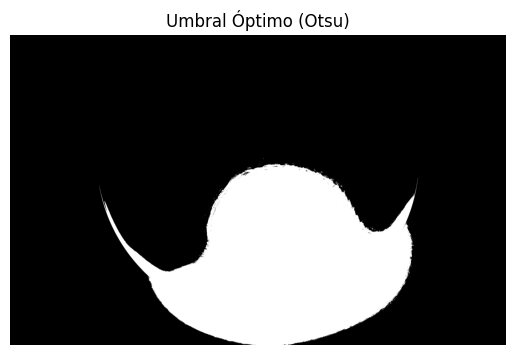

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(thresh_otsu, cmap='gray')
plt.title("Umbral Óptimo (Otsu)")
plt.axis('off')

Reducir a 100x100 en gris

(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

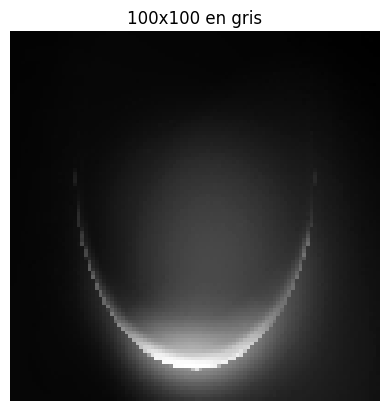

In [ ]:
small = cv2.resize(img, (100,100))
small_gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)

plt.imshow(small_gray, cmap='gray')
plt.title("100x100 en gris")
plt.axis('off')

Fondo rojo + umbral para detectar el círculo

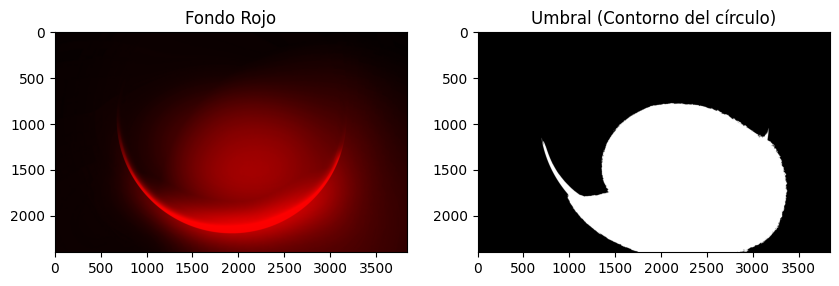

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Fondo rojo
fondo_rojo = img.copy()
fondo_rojo[:,:,1] = 0
fondo_rojo[:,:,0] = 0

# Separar canales
b, g, r = cv2.split(img)

# 🔥 Normalizar rojo para mejorar contraste
r_norm = cv2.normalize(r, None, 0, 255, cv2.NORM_MINMAX)

# 🔥 Suavizar para evitar ruido
blur = cv2.GaussianBlur(r_norm, (5,5), 0)

# 🔥 Umbral dinámico (mejor que Otsu aquí)
umbral = np.mean(blur) + 30
_, thresh = cv2.threshold(blur, umbral, 255, cv2.THRESH_BINARY)

# 🔥 Detectar bordes (CLAVE para contorno)
edges = cv2.Canny(blur, 50, 150)

# 🔥 Limpiar bordes
kernel = np.ones((3,3), np.uint8)
edges = cv2.dilate(edges, kernel, iterations=1)

# 🔥 (Opcional pero potente) detectar círculo real
circles = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=100,
    param1=50,
    param2=30,
    minRadius=50,
    maxRadius=1000
)

# Dibujar círculo detectado
contorno_final = np.zeros_like(edges)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for x, y, r in circles[0]:
        cv2.circle(contorno_final, (x,y), r, 255, 2)

# Mostrar resultados
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(fondo_rojo, cv2.COLOR_BGR2RGB))
plt.title("Fondo Rojo")

plt.subplot(1,3,2)
plt.imshow(edges, cmap='gray')
plt.title("Bordes (Canny)")

plt.subplot(1,3,3)
plt.imshow(contorno_final, cmap='gray')
plt.title("Contorno del círculo")

plt.show()